### Implement simulator

In [79]:
import os
import math
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
%matplotlib inline
from IPython.display import clear_output

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_folder = "drive/MyDrive/mestrado_final_files/models/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_folder = "G:\Meu Drive\mestrado_final_files\models\\"

In [80]:
print(f"Pandas version: {pd.__version__},\nNumpy Version: {np.__version__},\
      \nTorch Version: {torch.__version__},\nMatplotlib Version: {plt.matplotlib.__version__}")

Pandas version: 2.2.3,
Numpy Version: 2.2.6,      
Torch Version: 2.8.0+cpu,
Matplotlib Version: 3.10.0


In [3]:
pd.set_option("display.expand_frame_repr", False)

In [4]:

df_games_nba = pd.read_csv(data_folder + "games_nba.csv", sep = ';')\
[['GAME_ID', 'HOME_TEAM_ID', 'AWAY_TEAM_ID', 'HOME_TEAM', 'AWAY_TEAM', 'GAME_DATE', 'HOME_PTS', 'AWAY_PTS']]

columns_boxscore = ["home_FGM", "away_FGM", "home_FGA", "away_FGA", "home_FGP", "away_FGP", 
                    "home_3FGM", "away_3FGM", "home_3FGA", "away_3FGA", "home_3FGP", "away_3FGP", 
                    "home_FTM", "away_FTM", "home_FTA", "away_FTA", "home_FTP", "away_FTP", 
                    "home_RebOff", "away_RebOff", "home_RebDef", "away_RebDef", "home_RebTot", 
                    "away_RebTot", "home_AST", "away_AST", "home_STL", "away_STL", "home_BLK", 
                    "away_BLK", "home_TO", "away_TO", "home_FP", "away_FP", "home_points", 
                    "away_points", "home_PMP", "away_PMP", "home_outcome", 'away_outcome']

df_boxscore = pd.read_csv(data_folder + 'boxscore_moving_average20.txt', sep = ';')\
.set_index("game_id")\
[columns_boxscore]

In [5]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

# Convert the index of tokens_info to a list of tokens
list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}

# tokens_info = tokens_info\
# .query("hpts != 0 or vpts != 0 or limhteam != 0 or limvteam != 0")\
# .to_dict(orient = 'index')


In [6]:
tokens_info\
.assign(indice = lambda x: [token_to_integer[i] for i in x.index])\
.query("hpts > 0")\
.query("hpts == 3")

,n,cnt,cod,hpts,vpts,limhteam,limvteam,indice
token,,,,,,,,
p400_1(3)p541_6(11a)p400_3(11c),3,1370,_1(3)_6(11a)_3(11c),3,0,0,-1,16
p400_1(3)p541_6(11p)p400_3(11c),3,442,_1(3)_6(11p)_3(11c),3,0,0,-1,22
p440_1(3a)p541_6(11a)p400_3(11c),3,1914,_1(3a)_6(11a)_3(11c),3,0,0,-1,32
p440_1(3a)p541_6(11a)p550_8(0)p400_3(11c),4,407,_1(3a)_6(11a)_8(0)_3(11c),3,0,0,-1,36
p440_1(3a)p541_6(11p)p400_3(11c),3,508,_1(3a)_6(11p)_3(11c),3,0,0,-1,40
p400_1(4)p541_6(11a)p400_3(11c),3,876,_1(4)_6(11a)_3(11c),3,0,0,-1,52
p440_1(4a)p541_6(11a)p400_3(11c),3,550,_1(4a)_6(11a)_3(11c),3,0,0,-1,58
p400_1(5),1,15362,_1(5),3,0,0,0,60
p440_1(5a),1,72327,_1(5a),3,0,0,0,62


In [20]:
VOCAB_SIZE = 601
TIME_SIZE = 301
BATCH_SIZE = 8192
TRAIN_STEPS = 50001
run_models = 1

In [35]:
full_covariables = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 'limhfouls', 'limvfouls', 'dif', 'dif_20', 'ind_close_3',
                    'ind_close_5', 'ind_close_8', 'ind_blowout_15', 'ind_last_2_minutes', 'ind_last_minute', 'ind_last_20_seconds', 'ind_last_10_seconds', 
                    'lead', 'home_lead', 'away_lead', 'ind_last_2_minutes_game', 'ind_last_minute_game', 'ind_last_20_seconds_game', 
                    'ind_last_10_seconds_game', 'ind_clutch_2_last_minutes', 'ind_clutch_2_last_minutes_home', 'ind_clutch_2_last_minutes_away',
                    'ind_clutch_last_minute', 'ind_clutch_last_minute_home', 'ind_clutch_last_minute_away', 'ind_clutch_last_20_seconds',
                    'ind_clutch_last_20_seconds_home', 'ind_clutch_last_20_seconds_away', 'ind_clutch_last_10_seconds', 'ind_clutch_last_10_seconds_home',
                    'ind_clutch_last_10_seconds_away', 'ind_blowout_last_minute', 'ball_possession', 'home_FGM', 'away_FGM', 'home_FGA', 'away_FGA', 
                    'home_FGP', 'away_FGP', 'home_3FGM', 'away_3FGM', 'home_3FGA', 'away_3FGA', 'home_3FGP', 'away_3FGP', 'home_FTM', 'away_FTM', 
                    'home_FTA', 'away_FTA', 'home_FTP', 'away_FTP', 'home_RebOff', 'away_RebOff', 'home_RebDef', 'away_RebDef', 'home_RebTot', 
                    'away_RebTot', 'home_AST', 'away_AST', 'home_STL', 'away_STL', 'home_BLK', 'away_BLK', 'home_TO', 'away_TO', 'home_FP', 
                    'away_FP', 'home_points', 'away_points', 'home_PMP', 'away_PMP', 'home_outcome', 'away_outcome', 'playoff_game']


covariables_model = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 
                     'limhfouls', 'limvfouls', 'dif', 'ind_last_minute', 'ind_last_20_seconds',
                     'ind_last_10_seconds', 'lead', 'ball_possession']

covariables_model = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 'limhfouls', 'limvfouls', 'dif_20', 'ind_close_3',
                    'ind_close_5', 'ind_close_8', 'ind_blowout_15', 'ind_last_2_minutes', 'ind_last_minute', 'ind_last_20_seconds', 'ind_last_10_seconds', 
                    'home_lead', 'away_lead', 'ind_last_2_minutes_game', 'ind_last_minute_game', 'ind_last_20_seconds_game', 
                    'ind_last_10_seconds_game', 'ind_clutch_2_last_minutes', 'ind_clutch_2_last_minutes_home', 'ind_clutch_2_last_minutes_away',
                    'ind_clutch_last_minute', 'ind_clutch_last_minute_home', 'ind_clutch_last_minute_away', 'ind_clutch_last_20_seconds',
                    'ind_clutch_last_20_seconds_home', 'ind_clutch_last_20_seconds_away', 'ind_clutch_last_10_seconds', 'ind_clutch_last_10_seconds_home',
                    'ind_clutch_last_10_seconds_away', 'ind_blowout_last_minute', 'ball_possession']

index_covariables = [i for i, var in enumerate(full_covariables) if var in covariables_model]

covariables_model2 = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 'limhfouls', 'limvfouls', 'dif', 'ind_last_minute',
                     'ind_last_20_seconds', 'ind_last_10_seconds', 'lead', 'ball_possession']

index_covariables2 = [i for i, var in enumerate(full_covariables) if var in covariables_model2]

In [63]:
%run 02_functions_simulations.ipynb

In [64]:
CONTEXT_SIZE = 5
EMBEDDING_LAYER_SIZE = 64

In [65]:
model_file = models_folder + 'model_ngram_tokens_new_variables_parameters.pth'
#model_file = models_folder + 'model_token_simplevars_context5_emb64_hiddenlayers3_numneurons100_multiplicador3_parameters.pth'

new_token_model = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                       numerical_input_dim = len(index_covariables), num_hidden_neurons = [100, 100, 100], 
                                       num_layers = 3, activation = nn.GELU)

new_token_model.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_token_model.eval()

NGramModel_ExtraInfo(
  (embedding): Embedding(601, 64)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=357, out_features=100, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.0, inplace=False)
    (9): Linear(in_features=100, out_features=601, bias=True)
  )
)

In [66]:
model_file = models_folder + 'model_ngram_time_new_variables_parameters.pth'

new_time_model = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(covariables_model),
                                num_hidden_neurons = [100, 100, 100], num_layers = 3,
                                activation_function = nn.GELU, dropout_rate = 0.3)

new_time_model.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
new_time_model.eval()

SpentTimeModel(
  (embedding): Embedding(601, 64)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=357, out_features=100, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=100, out_features=301, bias=True)
  )
)

In [67]:
model_file = models_folder + 'model_ngram_tokens_old_variables_parameters.pth'
#model_file = models_folder + 'model_token_simplevars_context5_emb64_hiddenlayers3_numneurons100_multiplicador3_parameters.pth'

old_token_model = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                       numerical_input_dim = len(index_covariables2), num_hidden_neurons = [100, 100, 100], 
                                       num_layers = 3, activation = nn.GELU)

old_token_model.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
old_token_model.eval()

NGramModel_ExtraInfo(
  (embedding): Embedding(601, 64)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=334, out_features=100, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.0, inplace=False)
    (9): Linear(in_features=100, out_features=601, bias=True)
  )
)

In [68]:
model_file = models_folder + 'model_ngram_time_old_variables_parameters.pth'

old_time_model = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(covariables_model2),
                                num_hidden_neurons = [100, 100, 100], num_layers = 3,
                                activation_function = nn.GELU, dropout_rate = 0.3)

old_time_model.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
old_time_model.eval()

SpentTimeModel(
  (embedding): Embedding(601, 64)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=334, out_features=100, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=100, out_features=301, bias=True)
  )
)

In [ ]:
desktop_folder = "C:/Users/User/Desktop//"

model_file = desktop_folder + 'VARIATION_PROBLEM_num_ngram_model_parameters1.pth'
#model_file = models_folder + 'model_token_simplevars_context5_emb64_hiddenlayers3_numneurons100_multiplicador3_parameters.pth'

current_token_model = NGramModel_ExtraInfo(context_size = 5, vocab_size = VOCAB_SIZE, embedding_dim = 32, 
                                           numerical_input_dim = len(index_covariables2), num_hidden_neurons = [50, 50, 50], 
                                           num_layers = 3, activation = nn.GELU)

current_token_model.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
current_token_model.eval()

NGramModel_ExtraInfo(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=174, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.0, inplace=False)
    (9): Linear(in_features=50, out_features=601, bias=True)
  )
)

In [70]:
desktop_folder = "C:/Users/User/Desktop//"


model_file = desktop_folder + 'VARIATION_PROBLEM_time_model_parameters.pth'
#model_file = models_folder + 'model_token_simplevars_context5_emb64_hiddenlayers3_numneurons100_multiplicador3_parameters.pth'

current_time_model = SpentTimeModel(context_size = 5, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                    embedding_dim = 32, numerical_input_dim = len(covariables_model2),
                                    num_hidden_neurons = [50, 50, 50], num_layers = 3,
                                    activation_function = nn.GELU, dropout_rate = 0.3)

current_time_model.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
current_time_model.eval()

SpentTimeModel(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=174, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=50, out_features=301, bias=True)
  )
)

In [71]:
%run 02_functions_simulations.ipynb

In [72]:
len(covariables_model)

37

In [73]:
xdf0 = generate_game_plays(token_model = current_token_model, time_model = current_time_model, num_simulations = 10000, token_context = 5, num_numerical_variables = 14, config = 1)

Period: 7
keep_generating vector distribution: {0: 10000}
                  count      mean        std   min    1%    5%   10%    25%    50%    75%    90%    95%    99%    max
home_points       10000  112.4058  12.002155  67.0  85.0  93.0  97.0  104.0  112.0  121.0  128.0  132.0  140.0  157.0
away_points       10000  109.9054  11.933694  64.0  83.0  91.0  95.0  102.0  110.0  118.0  125.0  130.0  139.0  156.0
perc_played_time  10000    0.0500   2.235509   0.0   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 4437, np.str_('home'): 5563}


In [74]:
xdf1 = generate_game_plays(token_model = old_token_model, time_model = old_time_model, num_simulations = 10000, token_context = 5, num_numerical_variables = 14)

Period: 7
keep_generating vector distribution: {0: 10000}
                  count      mean        std   min    1%    5%   10%    25%    50%    75%    90%    95%    99%    max
home_points       10000  113.1319  11.939837  70.0  86.0  94.0  98.0  105.0  113.0  121.0  129.0  133.0  142.0  161.0
away_points       10000  111.1007  11.863817  65.0  84.0  92.0  96.0  103.0  111.0  119.0  126.0  131.0  140.0  158.0
perc_played_time  10000    0.0100   0.999950   0.0   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 4486, np.str_('home'): 5514}


In [76]:
xdf2 = generate_game_plays(token_model = new_token_model, time_model = new_time_model, num_simulations = 10000, token_context = 5, num_numerical_variables = 37, config = 2)

Period: 7
keep_generating vector distribution: {0: 10000}
                  count      mean        std   min    1%    5%    10%    25%    50%    75%    90%     95%    99%    max
home_points       10000  116.3551  12.971292  74.0  88.0  96.0  100.0  107.0  116.0  125.0  133.0  138.05  148.0  166.0
away_points       10000  112.7042  10.336029  70.0  89.0  96.0  100.0  106.0  113.0  120.0  126.0  130.00  138.0  161.0
perc_played_time  10000    0.0100   0.999950   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.00    0.0  100.0
Result: {np.str_('away'): 4236, np.str_('home'): 5764}


In [12]:
# covariables_model = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 
#                      'limhfouls', 'limvfouls', 'dif', 'ind_last_minute', 'ind_last_20_seconds',
#                      'ind_last_10_seconds', 'lead', 'ball_possession', 
#                      'home_3FGM', 'away_3FGM', 'home_3FGA', 'away_3FGA', 'home_FTM', 'away_FTM', 
#                      'home_FTA', 'away_FTA', 'home_RebOff', 'away_RebOff', 'home_RebDef', 'away_RebDef', 
#                      'home_AST', 'away_AST', 'home_STL', 'away_STL', 'home_BLK', 'away_BLK', 
#                      'home_TO', 'away_TO', 'home_FP', 'away_FP', 'home_points', 'away_points', 
#                      'playoff_game']

# #'home_outcome', 'away_outcome', 

# index_covariables = [i for i, var in enumerate(full_covariables) if var in covariables_model]

# model_file = models_folder + 'model_token_teamvars_context5_emb16_hiddenlayers3_numneurons100_multiplicador1_parameters.pth'

# num_ngram_model_some_variables = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
#                                                       numerical_input_dim = len(index_covariables), num_hidden_neurons = [100, 100, 100], 
#                                                       num_layers = 3, activation = nn.ReLU)

# num_ngram_model_some_variables.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
# num_ngram_model_some_variables.eval()

In [13]:
# pd.DataFrame(num_ngram_model_some_variables.embedding.weight.data)\
# .describe(percentiles = [.01, .05, .1, .25, .5, .75, .90, .95, .99]).T.round(2)

In [418]:
covariables_model = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'last_time', 
                     'limhfouls', 'limvfouls', 'dif', 'ind_last_minute', 'ind_last_20_seconds',
                     'ind_last_10_seconds', 'lead', 'ball_possession']

index_covariables = [i for i, var in enumerate(full_covariables) if var in covariables_model]

In [419]:
model_file = models_folder + 'model_time_simplevars_context5_emb16_hiddenlayers3_numneurons100_multiplicador1_parameters.pth'
#model_file = models_folder + 'model_time_simplevars_context5_emb64_hiddenlayers3_numneurons100_multiplicador1_parameters.pth'

simple_time_model = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                   embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(covariables_model),
                                   num_hidden_neurons = [100, 100, 100], num_layers = 3, activation_function = nn.GELU)

simple_time_model.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
simple_time_model.eval()


SpentTimeModel(
  (embedding): Embedding(601, 16)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=94, out_features=100, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.0, inplace=False)
    (9): Linear(in_features=100, out_features=301, bias=True)
  )
)

In [16]:
# covariables_model = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 
#                      'limhfouls', 'limvfouls', 'dif', 'ind_last_minute', 'ind_last_20_seconds',
#                      'ind_last_10_seconds', 'lead', 'ball_possession', 
#                      'home_3FGM', 'away_3FGM', 'home_3FGA', 'away_3FGA', 'home_FTM', 'away_FTM', 
#                      'home_FTA', 'away_FTA', 'home_RebOff', 'away_RebOff', 'home_RebDef', 'away_RebDef', 
#                      'home_AST', 'away_AST', 'home_STL', 'away_STL', 'home_BLK', 'away_BLK', 
#                      'home_TO', 'away_TO', 'home_FP', 'away_FP', 'home_points', 'away_points', 
#                      'home_outcome', 'away_outcome', 'playoff_game']

# full_time_model = SpentTimeModel(
#         context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
#         embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(covariables_model),
#         num_hidden_neurons = [100, 100, 100], num_layers = 3, activation_function = nn.ReLU)

# full_time_model.load_state_dict(torch.load('full_time_model_parameters.pth', weights_only = True))
# full_time_model.eval()



In [17]:
# with open('playbyplay_data_python.pkl', 'rb') as f:
#     pbp = pickle.load(f)

In [18]:
# games_test = pbp['test']['game_id'].drop_duplicates().to_list()

# columns_boxscore = ['home_3FGM', 'away_3FGM', 'home_3FGA', 'away_3FGA', 'home_FTM', 'away_FTM',
#                     'home_FTA', 'away_FTA', 'home_RebOff', 'away_RebOff', 'home_RebDef', 'away_RebDef',
#                     'home_AST', 'away_AST', 'home_STL', 'away_STL', 'home_BLK', 'away_BLK',
#                     'home_TO', 'away_TO', 'home_FP', 'away_FP', 'home_points', 'away_points', 
#                     'home_outcome', 'away_outcome', 'playoff_game']

# df_boxscore_test = normalize_boxscore_variables(df_boxscore)\
# .assign(playoff_game = lambda x: [0 if str(i)[0] == '2' else 1 for i in x.index])\
# .loc[games_test]

# df_games_nba_test = df_games_nba.set_index('GAME_ID').loc[games_test]

In [19]:
# df_boxscore_test[columns_boxscore]

In [20]:
# df_games_nba_test

In [21]:
# del pbp

In [22]:
# xdf, df_points = generate_game_plays(token_model = token_model, time_model = time_model, num_simulations = 1000,
#                                      token_vector =  [0] * 5, numerical_vector = [0.] * 14)
# xdf = xdf\
# .drop(columns = ["token_variables", "numerical_variables"])

### Functions

In [420]:
%run 02_functions_simulations.ipynb

In [ ]:
#desktop_path = "C:/Users/User/Desktop//"

# full_covariables = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 'limhfouls', 'limvfouls', 'dif', 'ind_last_minute', 
#                     'ind_last_20_seconds', 'ind_last_10_seconds', 'lead', 'ball_possession', 'home_FGM', 'away_FGM', 'home_FGA', 'away_FGA', 
#                     'home_FGP', 'away_FGP', 'home_3FGM', 'away_3FGM', 'home_3FGA', 'away_3FGA', 'home_3FGP', 'away_3FGP', 'home_FTM', 'away_FTM', 
#                     'home_FTA', 'away_FTA', 'home_FTP', 'away_FTP', 'home_RebOff', 'away_RebOff', 'home_RebDef', 'away_RebDef', 'home_RebTot', 
#                     'away_RebTot', 'home_AST', 'away_AST', 'home_STL', 'away_STL', 'home_BLK', 'away_BLK', 'home_TO', 'away_TO', 'home_FP', 
#                     'away_FP', 'home_points', 'away_points', 'home_PMP', 'away_PMP', 'home_outcome', 'away_outcome', 'playoff_game']

# covariables_model = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 
#                      'limhfouls', 'limvfouls', 'dif', 'ind_last_minute', 'ind_last_20_seconds',
#                      'ind_last_10_seconds', 'lead', 'ball_possession']

# index_covariables = [i for i, var in enumerate(full_covariables) if var in covariables_model]

# token_model = NGramModel_ExtraInfo(context_size = 5, vocab_size = VOCAB_SIZE, embedding_dim = 32, 
#                                    numerical_input_dim = len(index_covariables), num_hidden_neurons = [50, 50, 50], 
#                                    num_layers = 3, activation = nn.GELU, dropout_rate = 0.3)

# token_model.load_state_dict(torch.load(desktop_path + 'VARIATION_PROBLEM_num_ngram_model_parameters1.pth', weights_only = True))
# token_model.eval()

# time_model = SpentTimeModel(context_size = 5, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
#                             embedding_dim = 32, numerical_input_dim = len(covariables_model),
#                             num_hidden_neurons = [50, 50, 50], num_layers = 3,
#                             activation_function = nn.GELU, dropout_rate = 0.3)

# time_model.load_state_dict(torch.load(desktop_path + 'VARIATION_PROBLEM_time_model_parameters.pth', weights_only = True))
# time_model.eval()

SpentTimeModel(
  (embedding): Embedding(601, 32)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=174, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=50, out_features=50, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=50, out_features=301, bias=True)
  )
)

In [421]:
xdf2 = generate_game_plays(token_model = num_ngram_model, time_model = simple_time_model, num_simulations = 10000, token_context = 5, num_numerical_variables = 14)

Period: 7
keep_generating vector distribution: {0: 10000}
                  count      mean        std   min    1%     5%    10%    25%    50%    75%    90%    95%    99%    max
home_points       10000  118.9641  12.126608  72.0  92.0  100.0  104.0  111.0  119.0  127.0  135.0  140.0  148.0  164.0
away_points       10000  119.2094  11.791698  78.0  93.0  100.0  104.0  111.0  119.0  127.0  135.0  139.0  147.0  167.0
perc_played_time  10000    0.0200   1.414072   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 5051, np.str_('home'): 4949}


In [422]:
list_points = []
list_labels = ["a. ( < -20)", "b. (entre -20 e -10)", "c. (entre -10 e -5)", "d. (entre -5 e -3)", "e. (entre -3 e 3)", "f. (entre 3 e 5)", "g. (entre 5 e 10)", "h. (entre 10 e 20)", "i. ( > 20)"]
for p in [1, 2, 3, 4]:
    for t in [7200, 6600, 6000, 5400, 4800, 4200, 3600, 3000, 2400, 1800, 1200, 600, 200, 100, 0]:
        print(p, t)
        df_ = xdf2\
        .query("period == @p & remaining_time >= @t")\
        .groupby("sim_id")\
        .apply(lambda df: df.iloc[[-1]], include_groups = False)\
        .assign(dif_pts = lambda df: df["home_points"] - df['away_points'])\
        .assign(cat_dif = lambda df: pd.cut(df["dif_pts"], bins = [-100, -20, -10, -5, -3, 3, 5, 10, 20, 100], labels = list_labels))\
        .assign(cat_dif = lambda df: df["cat_dif"].astype('str'))\
        .groupby(["cat_dif"], observed = False)\
        .apply(lambda df: df[["home_points", "away_points"]].describe().T, include_groups = False)\
        .reset_index()\
        .assign(period = p, ref_remaining_time = t)

        list_points.append(df_)
        clear_output(wait = True)



4 0


In [423]:
df0 = pd.concat(list_points)\
.sort_values(["cat_dif", "level_1", "period", "ref_remaining_time"], ascending = [True, True, True, False])\
.assign(lag_pts = lambda df: df.groupby(["cat_dif", "level_1"])["mean"].shift(1).fillna(0))\
.assign(lag_cnt = lambda df: df.groupby(["cat_dif", "level_1"])["count"].shift(1).fillna(0))\
.assign(pts = lambda df: df["mean"] - df["lag_pts"])\
.query("count >= 100 & lag_cnt >= 100")\
.pivot_table(index = ["ref_remaining_time", "cat_dif"], columns = ["level_1", "period"], values = "pts")\
.reset_index()\
.sort_values(["cat_dif", "ref_remaining_time"], ascending = [True, False])\
.reset_index(drop = True)

df0.columns = ["ref_remaining_time", "cat_dif", "away_pts1", "away_pts2", "away_pts3", "away_pts4", "home_pts1", "home_pts2", "home_pts3", "home_pts4"]

In [424]:
df0.query("ref_remaining_time == 600").describe()

,ref_remaining_time,away_pts1,away_pts2,away_pts3,away_pts4,home_pts1,home_pts2,home_pts3,home_pts4
count,9.0,7.000000,9.000000,9.000000,9.000000,7.000000,9.000000,9.000000,9.000000
mean,600.0,2.555564,2.516628,2.506090,2.575016,2.547765,2.505266,2.535327,2.608637
std,0.0,0.060438,0.203219,0.136951,0.257314,0.062501,0.227124,0.179094,0.238888
min,600.0,2.452904,2.014500,2.233490,2.070010,2.443376,2.015258,2.281865,2.120495
25%,600.0,2.535925,2.506096,2.472005,2.508804,2.517766,2.506650,2.461005,2.469097
50%,600.0,2.564827,2.527596,2.523850,2.560342,2.546917,2.569536,2.495750,2.657900
75%,600.0,2.573167,2.614407,2.605775,2.747057,2.590262,2.631863,2.593230,2.775799
max,600.0,2.653035,2.731701,2.658875,2.881258,2.628008,2.766202,2.922710,2.885458


In [425]:
df_points_by_minute_by_diff.query("ref_remaining_time == 600").describe()

,ref_remaining_time,away_pts1,away_pts2,away_pts3,away_pts4,home_pts1,home_pts2,home_pts3,home_pts4
count,9.0,7.000000,8.000000,9.000000,9.000000,7.000000,8.000000,9.000000,9.000000
mean,600.0,2.351210,2.510453,2.355035,2.400579,2.303799,2.530086,2.393097,2.372219
std,0.0,0.131588,0.126829,0.190306,0.391530,0.115867,0.185023,0.237348,0.409491
min,600.0,2.209418,2.304741,2.116849,1.677908,2.144659,2.335175,2.086774,1.638814
25%,600.0,2.231174,2.433375,2.227743,2.365530,2.219575,2.400074,2.137058,2.151103
50%,600.0,2.344372,2.511639,2.377850,2.536262,2.301130,2.495231,2.450870,2.465829
75%,600.0,2.453533,2.579665,2.471666,2.665336,2.389678,2.605770,2.505151,2.616638
max,600.0,2.535266,2.727926,2.692289,2.853124,2.462293,2.903512,2.748221,2.885986


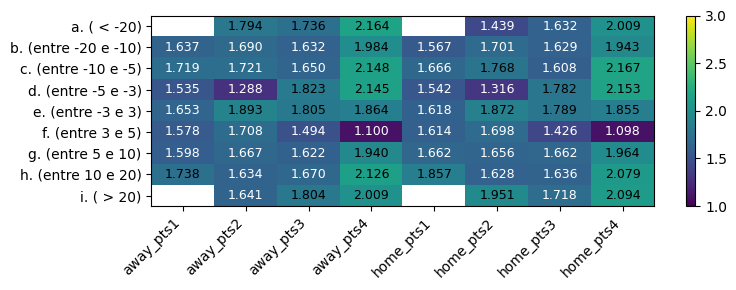

In [434]:
t = 200
df0\
.query("ref_remaining_time == @t")\
.drop(columns = "ref_remaining_time")\
.set_index("cat_dif")\
.pipe(heatmap_with_text, figsize = (8, 3), vmin = 1, vmax = 3)

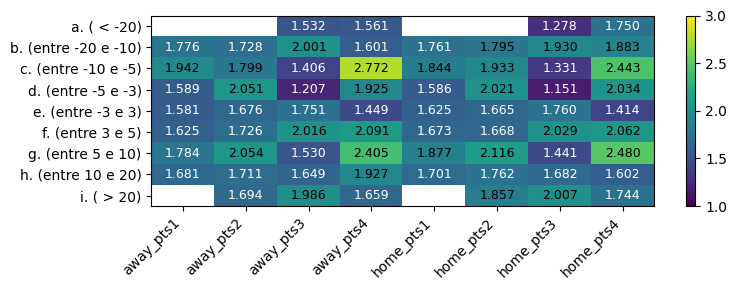

In [435]:
df_points_by_minute_by_diff\
.query("ref_remaining_time == @t")\
.drop(columns = "ref_remaining_time")\
.set_index("cat_dif")\
.pipe(heatmap_with_text, figsize = (8, 3), vmin = 1, vmax = 3)

In [292]:
def heatmap_with_text(df, cmap="viridis", fmt=".3f", figsize=(12,6), vmin = None, vmax = None):
    fig, ax = plt.subplots(figsize=figsize)

    data = df.values

    # Heatmap com escala fixa (se fornecida)
    im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)

    # Ticks
    ax.set_xticks(np.arange(df.shape[1]))
    ax.set_yticks(np.arange(df.shape[0]))

    ax.set_xticklabels(df.columns, rotation=45, ha="right")
    ax.set_yticklabels(df.index)

    # Texto dentro das células
    mid_val = np.nanmean(data)  # para escolher cor do texto
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            val = data[i, j]
            if not np.isnan(val):
                ax.text(j, i, format(val, fmt),
                        ha="center", va="center",
                        color="white" if val < mid_val else "black",
                        fontsize=9)

    # Barra de cores
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

In [350]:
with open(data_folder + "df_points_by_minute_by_diff.pkl", 'rb') as f:
    df_points_by_minute_by_diff = pickle.load(f)

df_points_by_minute_by_diff.columns = ["ref_remaining_time", "cat_dif", "away_pts1", "away_pts2", "away_pts3", "away_pts4", "home_pts1", "home_pts2", "home_pts3", "home_pts4"]

In [221]:
df0 = pd.concat(list_points)\
.sort_values(["index", "period", "ref_remaining_time"], ascending = [False, True, False])\
.assign(lag = lambda df: df.groupby("index")["mean"].shift(1).fillna(0))\
.assign(pts = lambda df: df["mean"] - df["lag"])\
.pivot_table(index = ["ref_remaining_time"], columns = ["index", "period"], values = "pts")\
.reset_index()\
.sort_values(["ref_remaining_time"], ascending = [False])\
.reset_index(drop = True)\
.set_index("ref_remaining_time")

df0.columns = ['away_points_1', 'away_points_2', 'away_points_3', 'away_points_4', 'home_points_1', 'home_points_2', 'home_points_3', 'home_points_4']


In [227]:
df0

,away_points_1,away_points_2,away_points_3,away_points_4,home_points_1,home_points_2,home_points_3,home_points_4
ref_remaining_time,,,,,,,,
7200,0.010,0.000,0.001,0.002,0.006,0.001,0.001,0.002
6600,1.780,1.844,1.791,1.954,1.847,1.903,1.825,1.882
6000,2.193,2.242,2.145,2.252,2.358,2.242,2.380,2.258
5400,2.267,2.281,2.225,2.228,2.202,2.290,2.223,2.259
4800,2.245,2.281,2.218,2.129,2.390,2.204,2.319,2.208
4200,2.274,2.247,2.185,2.149,2.305,2.356,2.246,2.177
3600,2.304,2.341,2.199,2.133,2.232,2.321,2.378,2.215
3000,2.230,2.260,2.181,2.269,2.295,2.300,2.307,2.271
2400,2.303,2.300,2.220,2.170,2.423,2.292,2.296,2.230


In [231]:
df1 = df0.query("ref_remaining_time < 7200") / real_data.query("ref_remaining_time < 7200")

<Axes: xlabel='spent_time'>

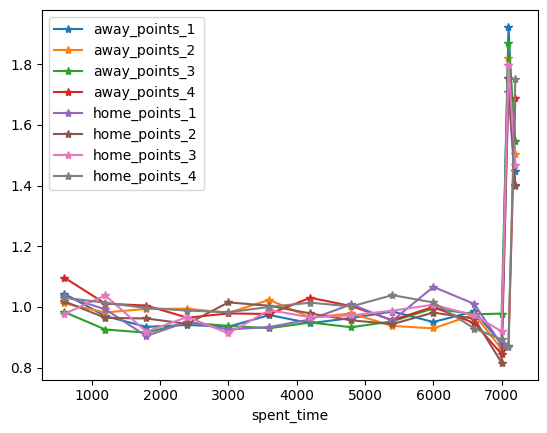

In [232]:
df1.assign(spent_time = lambda df: 7200 - df.index).set_index("spent_time").plot(marker = "*")

In [233]:
real_data

,away_points_1,away_points_2,away_points_3,away_points_4,home_points_1,home_points_2,home_points_3,home_points_4
ref_remaining_time,,,,,,,,
7200,0.000000,0.001233,0.004405,0.001586,0.000000,0.000881,0.003876,0.002467
6600,1.706131,1.822939,1.821705,1.782065,1.784179,1.869098,1.867865,1.826815
6000,2.261452,2.283650,2.317653,2.227977,2.377202,2.325758,2.293340,2.227273
5400,2.426357,2.295807,2.430937,2.218111,2.435518,2.380726,2.420366,2.267266
4800,2.387068,2.294397,2.338795,2.207364,2.512861,2.334390,2.398168,2.234672
4200,2.432699,2.291402,2.330867,2.196265,2.490310,2.321353,2.459831,2.216173
3600,2.367336,2.288231,2.364870,2.183756,2.390416,2.312192,2.402925,2.214940
3000,2.356589,2.341790,2.298978,2.202255,2.393587,2.350599,2.389006,2.239782
2400,2.390240,2.350775,2.379316,2.164200,2.402220,2.397463,2.361875,2.226568


In [234]:
df1

,away_points_1,away_points_2,away_points_3,away_points_4,home_points_1,home_points_2,home_points_3,home_points_4
ref_remaining_time,,,,,,,,
6600,1.043296,1.011553,0.983145,1.096481,1.035210,1.018138,0.977051,1.030208
6000,0.969731,0.981762,0.925505,1.010782,0.991922,0.963987,1.037788,1.013796
5400,0.934323,0.993550,0.915285,1.004458,0.904120,0.961891,0.918456,0.996354
4800,0.940484,0.994161,0.948352,0.964499,0.951107,0.944144,0.966988,0.988064
4200,0.934764,0.980622,0.937419,0.978479,0.925588,1.014925,0.913071,0.982324
3600,0.973246,1.023061,0.929861,0.976757,0.933729,1.003809,0.989627,1.000027
3000,0.946283,0.965074,0.948682,1.030308,0.958812,0.978474,0.965674,1.013938
2400,0.963502,0.978401,0.933041,1.002680,1.008650,0.956011,0.972109,1.001541
1800,0.984879,0.937611,0.952403,0.956558,0.954553,0.943229,0.987766,1.038857


In [167]:
real_data

,ref_remaining_time,away_points_1,away_points_2,away_points_3,away_points_4,home_points_1,home_points_2,home_points_3,home_points_4
0,7200,0.000000,0.001233,0.004405,0.001586,0.000000,0.000881,0.003876,0.002467
1,6600,1.706131,1.822939,1.821705,1.782065,1.784179,1.869098,1.867865,1.826815
2,6000,2.261452,2.283650,2.317653,2.227977,2.377202,2.325758,2.293340,2.227273
3,5400,2.426357,2.295807,2.430937,2.218111,2.435518,2.380726,2.420366,2.267266
4,4800,2.387068,2.294397,2.338795,2.207364,2.512861,2.334390,2.398168,2.234672
5,4200,2.432699,2.291402,2.330867,2.196265,2.490310,2.321353,2.459831,2.216173
6,3600,2.367336,2.288231,2.364870,2.183756,2.390416,2.312192,2.402925,2.214940
7,3000,2.356589,2.341790,2.298978,2.202255,2.393587,2.350599,2.389006,2.239782
8,2400,2.390240,2.350775,2.379316,2.164200,2.402220,2.397463,2.361875,2.226568
9,1800,2.374912,2.403982,2.342495,2.194327,2.396934,2.465997,2.394292,2.227449


In [83]:
xdf3 = generate_game_plays(token_model = num_ngram_model, time_model = simple_time_model, num_simulations = 10000, token_context = 5, num_numerical_variables = 14, constant_value = 1)

Period: 8
keep_generating vector distribution: {0: 10000}
                  count      mean        std   min    1%    5%    10%    25%    50%    75%    90%    95%    99%    max
home_points       10000  117.1232  11.849355  73.0  90.0  98.0  102.0  109.0  117.0  125.0  132.0  137.0  145.0  165.0
away_points       10000  111.9239  11.492933  74.0  87.0  93.0   97.0  104.0  112.0  120.0  127.0  131.0  140.0  156.0
perc_played_time  10000    0.0100   0.999950   0.0   0.0   0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  100.0
Result: {np.str_('away'): 3739, np.str_('home'): 6261}


In [191]:
with open(data_folder + "results_ngram_models_seasons_performance.pkl", 'rb') as f:
    list_performance = pickle.load(f)

In [192]:
list_performance[0]

{'token_model_name': 'ngram_token_model_season_201819_dropout03_parameters.pth',
 'token_model_config': {'embedding_layer_size': 32,
  'token_context_size': 5,
  'token_vocab_size': 601,
  'num_hidden_neurons': [50, 50, 50],
  'batch_size': 1024},
 'token_model_covariables': ['period1',
  'period2',
  'period3',
  'period4',
  'period_overtime',
  'time',
  'limhfouls',
  'limvfouls',
  'dif',
  'ind_last_minute',
  'ind_last_20_seconds',
  'ind_last_10_seconds',
  'lead',
  'ball_possession'],
 'token_model_train_loss': [6.392367362976074,
  6.381016254425049,
  6.369586944580078,
  6.362762451171875,
  6.343062877655029,
  6.325277805328369,
  6.308334827423096,
  6.286725997924805,
  6.270749568939209,
  6.233452320098877,
  6.201513767242432,
  6.162755489349365,
  6.115959644317627,
  6.045236110687256,
  5.976278781890869,
  5.909850120544434,
  5.815773010253906,
  5.651339054107666,
  5.623164176940918,
  5.448222637176514,
  5.358898162841797,
  5.253148555755615,
  5.18863248

In [84]:
xdf2\
.groupby(["sim_id", "period"], as_index = False, dropna = False).size()\
.groupby(["period"], as_index = False, dropna = False)["size"].describe()

,period,count,mean,std,min,25%,50%,75%,max
0,1,10000.0,111.5108,10.435371,71.0,104.0,111.0,118.0,162.0
1,2,10000.0,128.3600,14.073486,82.0,118.0,127.0,137.0,193.0
2,3,10000.0,132.5666,16.300796,84.0,121.0,132.0,143.0,207.0
3,4,10000.0,207.6975,27.364913,116.0,189.0,207.0,226.0,319.0
4,5,5.0,199.2000,60.565667,101.0,196.0,203.0,237.0,259.0


In [85]:
xdf3\
.groupby(["sim_id", "period"], as_index = False, dropna = False).size()\
.groupby(["period"], as_index = False, dropna = False)["size"].describe()

,period,count,mean,std,min,25%,50%,75%,max
0,1,10000.0,95.631300,9.679914,67.0,89.00,95.0,102.00,138.0
1,2,10000.0,98.777000,10.168963,65.0,92.00,98.0,105.00,145.0
2,3,10000.0,96.233900,9.917471,65.0,89.00,96.0,103.00,137.0
3,4,10000.0,98.725700,10.335112,65.0,91.00,98.0,105.00,143.0
4,5,211.0,41.241706,6.345104,27.0,37.00,41.0,45.00,66.0
5,6,23.0,40.826087,5.005925,33.0,37.50,40.0,43.00,54.0
6,7,2.0,45.500000,13.435029,36.0,40.75,45.5,50.25,55.0
7,8,1.0,44.000000,NaN,44.0,44.00,44.0,44.00,44.0


In [86]:
xdf2\
.groupby(["sim_id", "period"])\
.apply(lambda df: df.iloc[[-1]], include_groups = False)\
.groupby('period')[["home_points", 'away_points']].describe()

home_points                                                          away_points                                                        
             count      mean        std    min    25%    50%     75%    max       count      mean        std    min    25%    50%    75%    max
period                                                                                                                                         
1          10000.0   36.1067   6.738624   14.0   32.0   36.0   40.00   68.0     10000.0   29.8033   5.557616    9.0   26.0   30.0   34.0   50.0
2          10000.0   75.6002  10.521684   41.0   68.0   75.0   83.00  118.0     10000.0   60.2225   7.753051   28.0   55.0   60.0   65.0   90.0
3          10000.0  115.9408  14.299460   71.0  106.0  115.0  125.25  170.0     10000.0   91.3834   9.525328   43.0   85.0   91.0   98.0  136.0
4          10000.0  175.9581  18.954273  118.0  163.0  176.0  189.00  247.0     10000.0  131.4100  11.342785   76.0  124.0  131.0  139.0  185.0
5              5.0  169.6000  17.184295  145.0  164.0  171.0  176.00  192.0         5.0  156.0000   9.772410  142.0  152.0  156.0  163.0  167.0

In [87]:
xdf3\
.groupby(["sim_id", "period"])\
.apply(lambda df: df.iloc[[-1]], include_groups = False)\
.groupby('period')[["home_points", 'away_points']].describe()

home_points                                                           away_points                                                            
             count        mean        std    min    25%    50%    75%    max       count        mean        std    min     25%    50%     75%    max
period                                                                                                                                              
1          10000.0   29.175200   5.793484   10.0   25.0   29.0   33.0   54.0     10000.0   28.140700   5.703153    7.0   24.00   28.0   32.00   49.0
2          10000.0   58.513600   8.230601   29.0   53.0   58.0   64.0   91.0     10000.0   56.107300   8.018243   25.0   51.00   56.0   62.00   85.0
3          10000.0   87.855500  10.122483   42.0   81.0   88.0   95.0  126.0     10000.0   83.960800   9.776954   48.0   77.00   84.0   91.00  122.0
4          10000.0  116.846600  11.720333   73.0  109.0  117.0  125.0  165.0     10000.0  111.649800  11.228382   74.0  104.00  112.0  119.00  152.0
5            211.0  126.616114   8.009490  106.0  121.0  127.0  132.0  146.0       211.0  126.606635   8.566922  103.0  120.50  126.0  133.00  153.0
6             23.0  139.652174   8.369907  122.0  134.5  142.0  146.0  152.0        23.0  138.913043   9.258475  122.0  130.50  140.0  146.00  156.0
7              2.0  136.000000   2.828427  134.0  135.0  136.0  137.0  138.0         2.0  135.500000   2.121320  134.0  134.75  135.5  136.25  137.0
8              1.0  145.000000        NaN  145.0  145.0  145.0  145.0  145.0         1.0  140.000000        NaN  140.0  140.00  140.0  140.00  140.0

In [88]:
xdf2\
.groupby(["sim_id", "period"])\
.apply(lambda df: df.iloc[[-1]], include_groups = False)\
.groupby('period')[["limhteam", 'limvteam']].describe()

limhteam                                                limvteam                                                
          count     mean       std   min   25%   50%  75%  max    count     mean       std   min   25%   50%   75%  max
period                                                                                                                 
1       10000.0  -3.7571  2.329773 -13.0  -5.0  -4.0 -2.0  1.0  10000.0  -2.7120  2.138390 -13.0  -4.0  -2.0  -1.0  1.0
2       10000.0  -5.7167  2.697623 -17.0  -7.0  -6.0 -4.0  1.0  10000.0  -4.4461  2.620989 -17.0  -6.0  -4.0  -3.0  1.0
3       10000.0  -5.6897  2.689895 -19.0  -7.0  -6.0 -4.0  1.0  10000.0  -4.4649  2.679195 -17.0  -6.0  -4.0  -3.0  1.0
4       10000.0 -10.6721  3.676783 -26.0 -13.0 -11.0 -8.0  0.0  10000.0 -16.1221  4.594486 -34.0 -19.0 -16.0 -13.0  0.0
5           5.0  -6.2000  3.271085 -12.0  -5.0  -5.0 -5.0 -4.0      5.0  -9.6000  7.334848 -17.0 -16.0  -9.0  -7.0  1.0

In [89]:
xdf3\
.groupby(["sim_id", "period"])\
.apply(lambda df: df.iloc[[-1]], include_groups = False)\
.groupby('period')[["limhteam", 'limvteam']].describe()

limhteam                                                limvteam                                              
          count      mean       std   min   25%  50%  75%  max    count      mean       std   min  25%  50%  75%  max
period                                                                                                               
1       10000.0 -1.946100  1.923321 -11.0 -3.00 -2.0 -1.0  1.0  10000.0 -1.830400  1.877442 -13.0 -3.0 -2.0  0.0  1.0
2       10000.0 -2.237700  2.017723 -12.0 -3.00 -2.0 -1.0  1.0  10000.0 -2.179000  1.995534 -11.0 -3.0 -2.0 -1.0  1.0
3       10000.0 -2.102000  1.973470 -11.0 -3.00 -2.0 -1.0  1.0  10000.0 -2.007700  1.926814 -12.0 -3.0 -2.0 -1.0  1.0
4       10000.0 -2.246900  2.030210 -11.0 -3.25 -2.0 -1.0  1.0  10000.0 -2.190500  1.976259 -12.0 -3.0 -2.0 -1.0  1.0
5         211.0 -0.298578  1.242481  -5.0 -1.00  0.0  1.0  1.0    211.0 -0.203791  1.028723  -5.0 -1.0  0.0  1.0  1.0
6          23.0 -0.173913  0.936734  -2.0 -1.00  0.0  0.5  1.0     23.0  0.043478  0.877924  -2.0  0.0  0.0  1.0  1.0
7           2.0 -1.000000  1.414214  -2.0 -1.50 -1.0 -0.5  0.0      2.0  0.000000  0.000000   0.0  0.0  0.0  0.0  0.0
8           1.0  0.000000       NaN   0.0  0.00  0.0  0.0  0.0      1.0 -1.000000       NaN  -1.0 -1.0 -1.0 -1.0 -1.0

In [90]:
xdf2\
.assign(ind_h = lambda df: df.groupby(["sim_id", "period"])["home_points"].shift(1))\
.assign(ind_a = lambda df: df.groupby(["sim_id", "period"])["away_points"].shift(1))\
.query("ind_h.notna() & ind_a.notna()")\
.assign(ind_h = lambda df: (df["home_points"] > df["ind_h"]).astype(int))\
.assign(ind_a = lambda df: (df["away_points"] > df["ind_a"]).astype(int))\
.groupby(["sim_id", "period"])[["ind_h", 'ind_a']].sum()\
.reset_index()\
.groupby("period")[["ind_h", "ind_a"]].describe()

ind_h                                                     ind_a                                                
          count     mean       std   min   25%   50%   75%   max    count     mean       std  min   25%   50%   75%   max
period                                                                                                                   
1       10000.0  17.7344  3.366480   7.0  15.0  18.0  20.0  31.0  10000.0  15.5123  2.935355  5.0  14.0  15.0  17.0  28.0
2       10000.0  20.2133  4.112407   8.0  17.0  20.0  23.0  41.0  10000.0  16.7000  3.324320  5.0  14.0  17.0  19.0  31.0
3       10000.0  20.5749  4.379784   6.0  17.0  20.0  23.0  41.0  10000.0  16.9980  3.433915  5.0  15.0  17.0  19.0  32.0
4       10000.0  34.1358  6.249437  11.0  30.0  34.0  38.0  62.0  10000.0  22.7208  4.374673  7.0  20.0  23.0  26.0  43.0
5           5.0  23.2000  9.984989   8.0  21.0  24.0  28.0  35.0      5.0  14.4000  4.393177  8.0  12.0  16.0  17.0  19.0

In [91]:
xdf3\
.assign(ind_h = lambda df: df.groupby(["sim_id", "period"])["home_points"].shift(1))\
.assign(ind_a = lambda df: df.groupby(["sim_id", "period"])["away_points"].shift(1))\
.query("ind_h.notna() & ind_a.notna()")\
.assign(ind_h = lambda df: (df["home_points"] > df["ind_h"]).astype(int))\
.assign(ind_a = lambda df: (df["away_points"] > df["ind_a"]).astype(int))\
.groupby(["sim_id", "period"])[["ind_h", 'ind_a']].sum()\
.reset_index()\
.groupby("period")[["ind_h", "ind_a"]].describe()

ind_h                                                      ind_a                                                  
          count       mean       std  min   25%   50%   75%   max    count       mean       std  min   25%   50%   75%   max
period                                                                                                                      
1       10000.0  14.295400  2.867989  5.0  12.0  14.0  16.0  27.0  10000.0  13.850200  2.817686  4.0  12.0  14.0  16.0  26.0
2       10000.0  14.600100  2.964803  4.0  13.0  15.0  17.0  26.0  10000.0  13.996900  2.846384  4.0  12.0  14.0  16.0  26.0
3       10000.0  14.477900  2.909082  4.0  12.0  14.0  16.0  28.0  10000.0  13.805400  2.859047  5.0  12.0  14.0  16.0  25.0
4       10000.0  14.478300  2.954759  4.0  12.0  14.0  16.0  26.0  10000.0  13.888500  2.855641  5.0  12.0  14.0  16.0  26.0
5         211.0   5.781991  1.695894  2.0   5.0   6.0   7.0  10.0    211.0   5.744076  1.917563  2.0   4.0   6.0   7.0  11.0
6          23.0   6.217391  1.622471  4.0   5.0   6.0   7.0  10.0     23.0   5.782609  1.756974  3.0   4.0   6.0   7.0  10.0
7           2.0   6.000000  1.414214  5.0   5.5   6.0   6.5   7.0      2.0   7.000000  1.414214  6.0   6.5   7.0   7.5   8.0
8           1.0   4.000000       NaN  4.0   4.0   4.0   4.0   4.0      1.0   3.000000       NaN  3.0   3.0   3.0   3.0   3.0

In [92]:
xdf2\
.assign(play = lambda df: [integer_to_token[item] for item in df["token"]])\
.assign(ind_h = lambda df: df["play"].str.contains("4.._1\([1|2|3|4]").astype("int"))\
.assign(ind_a = lambda df: df["play"].str.contains("5.._1\([1|2|3|4]").astype("int"))\
.groupby(["sim_id", "period"])[["ind_h", 'ind_a']].sum()\
.reset_index()\
.groupby("period")[["ind_h", "ind_a"]].describe()

ind_h                                                   ind_a                                             
          count     mean       std  min  25%   50%   75%   max    count    mean       std  min  25%  50%   75%   max
period                                                                                                              
1       10000.0   9.4967  2.592655  1.0  8.0   9.0  11.0  21.0  10000.0  7.8412  2.325451  0.0  6.0  8.0   9.0  17.0
2       10000.0   9.7935  2.765289  2.0  8.0  10.0  12.0  24.0  10000.0  7.5030  2.343318  0.0  6.0  7.0   9.0  17.0
3       10000.0   9.9983  2.863235  1.0  8.0  10.0  12.0  21.0  10000.0  7.8072  2.395788  1.0  6.0  8.0   9.0  17.0
4       10000.0  10.5200  2.989096  1.0  8.0  10.0  12.0  23.0  10000.0  9.0533  2.676822  1.0  7.0  9.0  11.0  20.0
5           5.0   5.8000  2.049390  4.0  4.0   6.0   6.0   9.0      5.0  6.0000  1.870829  4.0  5.0  6.0   6.0   9.0

In [93]:
xdf3\
.assign(play = lambda df: [integer_to_token[item] for item in df["token"]])\
.assign(ind_h = lambda df: df["play"].str.contains("4.._1\([1|2|3|4]").astype("int"))\
.assign(ind_a = lambda df: df["play"].str.contains("5.._1\([1|2|3|4]").astype("int"))\
.groupby(["sim_id", "period"])[["ind_h", 'ind_a']].sum()\
.reset_index()\
.groupby("period")[["ind_h", "ind_a"]].describe()

ind_h                                                    ind_a                                                
          count      mean       std  min   25%  50%   75%   max    count      mean       std  min   25%  50%   75%   max
period                                                                                                                  
1       10000.0  7.528900  2.277253  0.0  6.00  7.0  9.00  17.0  10000.0  7.406900  2.269504  0.0  6.00  7.0  9.00  16.0
2       10000.0  7.424200  2.276966  1.0  6.00  7.0  9.00  18.0  10000.0  7.232300  2.245538  0.0  6.00  7.0  9.00  17.0
3       10000.0  7.503600  2.284449  0.0  6.00  7.0  9.00  17.0  10000.0  7.235400  2.244658  0.0  6.00  7.0  9.00  16.0
4       10000.0  7.283300  2.232877  0.0  6.00  7.0  9.00  16.0  10000.0  7.098800  2.240165  0.0  6.00  7.0  9.00  15.0
5         211.0  3.033175  1.299758  0.0  2.00  3.0  4.00   6.0    211.0  3.042654  1.506519  0.0  2.00  3.0  4.00   8.0
6          23.0  3.478261  1.309739  0.0  3.00  4.0  4.00   6.0     23.0  2.913043  1.703287  0.0  2.00  3.0  4.00   8.0
7           2.0  4.500000  2.121320  3.0  3.75  4.5  5.25   6.0      2.0  2.500000  0.707107  2.0  2.25  2.5  2.75   3.0
8           1.0  1.000000       NaN  1.0  1.00  1.0  1.00   1.0      1.0  2.000000       NaN  2.0  2.00  2.0  2.00   2.0

In [94]:
xdf2\
.assign(play = lambda df: [integer_to_token[item] for item in df["token"]])\
.assign(ind_h = lambda df: df["play"].str.contains("4.._1\(5").astype("int"))\
.assign(ind_a = lambda df: df["play"].str.contains("5.._1\(5").astype("int"))\
.groupby(["sim_id", "period"])[["ind_h", 'ind_a']].sum()\
.reset_index()\
.groupby("period")[["ind_h", "ind_a"]].describe()

ind_h                                                ind_a                                           
          count    mean       std  min  25%  50%  75%   max    count    mean       std  min  25%  50%  75%  max
period                                                                                                         
1       10000.0  3.1577  1.664664  0.0  2.0  3.0  4.0  11.0  10000.0  1.8350  1.284889  0.0  1.0  2.0  3.0  8.0
2       10000.0  3.1287  1.689563  0.0  2.0  3.0  4.0  11.0  10000.0  1.4922  1.182150  0.0  1.0  1.0  2.0  7.0
3       10000.0  3.2514  1.736807  0.0  2.0  3.0  4.0  14.0  10000.0  1.5078  1.196028  0.0  1.0  1.0  2.0  8.0
4       10000.0  3.1715  1.744303  0.0  2.0  3.0  4.0  11.0  10000.0  1.6292  1.269909  0.0  1.0  1.0  2.0  7.0
5           5.0  1.2000  1.303840  0.0  0.0  1.0  2.0   3.0      5.0  0.2000  0.447214  0.0  0.0  0.0  0.0  1.0

In [95]:
xdf3\
.assign(play = lambda df: [integer_to_token[item] for item in df["token"]])\
.assign(ind_h = lambda df: df["play"].str.contains("4.._1\(5").astype("int"))\
.assign(ind_a = lambda df: df["play"].str.contains("5.._1\(5").astype("int"))\
.groupby(["sim_id", "period"])[["ind_h", 'ind_a']].sum()\
.reset_index()\
.groupby("period")[["ind_h", "ind_a"]].describe()

ind_h                                                  ind_a                                              
          count      mean       std  min  25%  50%  75%   max    count      mean       std  min  25%  50%  75%   max
period                                                                                                              
1       10000.0  2.591500  1.515275  0.0  1.0  2.0  4.0   9.0  10000.0  2.376200  1.456051  0.0  1.0  2.0  3.0  10.0
2       10000.0  2.524200  1.465070  0.0  1.0  2.0  3.0   9.0  10000.0  2.269000  1.427951  0.0  1.0  2.0  3.0   9.0
3       10000.0  2.572400  1.509565  0.0  1.0  2.0  3.0  10.0  10000.0  2.318800  1.441865  0.0  1.0  2.0  3.0  10.0
4       10000.0  2.474300  1.497052  0.0  1.0  2.0  3.0  10.0  10000.0  2.256300  1.419159  0.0  1.0  2.0  3.0  10.0
5         211.0  0.962085  0.989701  0.0  0.0  1.0  1.0   5.0    211.0  0.919431  0.930003  0.0  0.0  1.0  1.0   4.0
6          23.0  0.782609  0.850482  0.0  0.0  1.0  1.0   3.0     23.0  0.869565  1.013740  0.0  0.0  1.0  1.5   3.0
7           2.0  1.000000  1.414214  0.0  0.5  1.0  1.5   2.0      2.0  1.000000  1.414214  0.0  0.5  1.0  1.5   2.0
8           1.0  1.000000       NaN  1.0  1.0  1.0  1.0   1.0      1.0  0.000000       NaN  0.0  0.0  0.0  0.0   0.0

In [26]:
xdf2.query("period <= 4").groupby(["sim_id", "period"]).apply(lambda df: df.iloc[[-1]], include_groups = False)\
.groupby("period")\
[["home_points", "away_points"]].describe()

home_points                                                        away_points                                                       
             count      mean        std   min    25%    50%    75%    max       count      mean        std   min    25%    50%    75%    max
period                                                                                                                                      
1          10000.0   29.1038   5.777280  10.0   25.0   29.0   33.0   49.0     10000.0   28.0514   5.665666   9.0   24.0   28.0   32.0   50.0
2          10000.0   58.4444   8.207426  21.0   53.0   58.0   64.0   93.0     10000.0   56.1631   7.965428  26.0   51.0   56.0   61.0   95.0
3          10000.0   87.7451  10.086422  42.0   81.0   88.0   95.0  128.0     10000.0   84.0043   9.737924  51.0   77.0   84.0   91.0  123.0
4          10000.0  116.8607  11.649913  67.0  109.0  117.0  125.0  168.0     10000.0  111.7815  11.301484  70.0  104.0  112.0  119.0  156.0

In [230]:
xdf1.query("period <= 4").groupby(["sim_id", "period"]).apply(lambda df: df.iloc[[-1]], include_groups = False)\
.groupby("period")\
[["home_points", "away_points"]].describe()

home_points                                                       away_points                                                      
             count     mean        std   min    25%    50%    75%    max       count     mean        std   min    25%    50%    75%    max
period                                                                                                                                    
1           1000.0   29.029   6.040583   9.0   25.0   29.0   33.0   50.0      1000.0   27.992   5.766384  11.0   24.0   28.0   32.0   49.0
2           1000.0   58.486   8.270805  34.0   53.0   58.0   64.0   88.0      1000.0   56.322   7.894849  34.0   51.0   57.0   61.0   86.0
3           1000.0   88.171  10.184964  57.0   81.0   88.0   95.0  124.0      1000.0   84.491   9.742527  58.0   78.0   84.0   91.0  121.0
4           1000.0  117.569  11.817906  86.0  109.0  117.0  125.0  162.0      1000.0  112.466  11.392921  81.0  104.0  112.0  120.0  151.0

In [225]:
xdf.query("period <= 4").groupby(["simulation", "period"]).apply(lambda df: df.iloc[[-1]], include_groups = False)\
.groupby("period")\
[["home_points", "away_points"]].describe()

home_points                                                       away_points                                                      
             count     mean        std   min    25%    50%    75%    max       count     mean        std   min    25%    50%    75%    max
period                                                                                                                                    
1.0         1000.0   28.170   5.869885  11.0   24.0   28.0   32.0   46.0      1000.0   27.466   5.609841  11.0   24.0   27.0   31.0   43.0
2.0         1000.0   56.939   8.309050  33.0   51.0   57.0   62.0   87.0      1000.0   55.040   8.034859  33.0   50.0   55.0   60.0   91.0
3.0         1000.0   85.564  10.369447  47.0   79.0   85.0   93.0  125.0      1000.0   82.224   9.670954  48.0   76.0   82.0   89.0  117.0
4.0         1000.0  113.916  12.004793  69.0  106.0  114.0  122.0  151.0      1000.0  109.709  10.854867  77.0  102.0  109.0  117.0  147.0

In [ ]:
# input
period = 1
token_model = num_ngram_model
time_model = simple_time_model
num_simulations = 1000
token_context = 5
num_numerical_variables = 14
#############################################

game_log = GameLog(n_sims = num_simulations)
game_status = GameStatus.from_initial(n_sims = num_simulations, window = token_context, n_features = num_numerical_variables)

valid_simulations = np.where((game_status.keep_generating > 0) & (game_status.keep_generating < 6))[0]

random_first_play(period = 1, game_status = game_status, valid_simulations = valid_simulations, token_model = token_model, constant_value = 3)

#spent_time = [0] * num_simulations
period_duration = 7200 if period <= 4 else 3000

while len(valid_simulations) > 0:
    clear_output(wait = True)   
    game_log.add_events(indices = valid_simulations, game_status = game_status)

    list_limhteam = game_status.limhteam.copy()
    list_limvteam = game_status.limvteam.copy()

    random_play_loop(period = period, game_status = game_status, valid_simulations = valid_simulations, 
                     token_model = token_model, time_model = time_model, constant_value = 3)

    change_fouls_limit_two_final_minutes(game_status = game_status, valid_simulations = valid_simulations, 
                                         list_limhteam = list_limhteam, list_limvteam = list_limvteam)

    # keep_generating = 0: nao precisa gerar mais nada
    mask_kp = (game_status.keep_generating == 2)
    idx_kp = np.where(mask_kp)[0]
    game_status.keep_generating[idx_kp] = 0

    # keep_generating = 6: so precisa gerar a jogada de encerramento
    mask_kp = (game_status.keep_generating == 3) | (game_status.keep_generating == 5)
    idx_kp = np.where(mask_kp)[0]
    game_status.keep_generating[idx_kp] = 6

    valid_simulations = np.where((game_status.keep_generating > 0) & (game_status.keep_generating < 6))[0]

    print_status(game_status = game_status, period = period)

valid_simulations = np.where((game_status.keep_generating >= 6))[0]

random_last_play(period = period, game_status = game_status, valid_simulations = valid_simulations, 
                 token_model = token_model, constant_value = 3)

game_log.add_events(indices = valid_simulations, game_status = game_status)

print_status(game_status = game_status, period = period)

Period: 1
keep_generating vector distribution: {0: 1000}
                  count     mean       std    min     1%     5%    10%    25%    50%    75%    90%    95%     99%    max
home_points        1000   30.006  5.637549   14.0   17.0   21.0   23.0   26.0   30.0   34.0   37.0   39.0   44.01   50.0
away_points        1000   29.319  5.917706   10.0   15.0   20.0   22.0   25.0   29.0   33.0   37.0   39.0   43.00   47.0
perc_played_time   1000  100.000  0.000000  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.0  100.00  100.0


In [127]:
game_log.to_dataframe()

,sim_id,step,period,remaining_time,token,prob,time,home_points,away_points,limhteam,limvteam,ball_possession,keep_generating
0,0,0,1,7200,87,0.483102,0,0,0,4,4,-1,1
1,0,1,1,6980,141,0.009992,220,0,0,4,4,-1,1
2,0,2,1,6950,240,0.266698,30,0,0,4,4,-1,1
3,0,3,1,6920,119,0.031048,30,0,0,4,4,-1,1
4,0,4,1,6910,239,0.517139,10,0,0,4,4,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96075,999,81,1,138,28,0.034694,160,28,32,-2,0,1,1
96076,999,82,1,2,163,0.005677,136,28,32,-2,0,1,1
96077,999,83,1,2,240,0.189864,0,28,32,-2,0,1,1
96078,999,84,1,2,129,0.024193,0,28,32,-2,0,1,1


### New simulation

In [47]:
df_games_nba_test\
.reset_index()\
.assign(dif = lambda x: x['HOME_PTS'] - x['AWAY_PTS'])\
.sort_values("dif")

,GAME_ID,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,GAME_DATE,HOME_PTS,AWAY_PTS,dif
554,22201145,1610612757,1610612758,Portland Trail Blazers,Sacramento Kings,2023-03-29,80,120,-40
308,22000808,1610612753,1610612749,Orlando Magic,Milwaukee Bucks,2021-04-11,87,124,-37
425,22101094,1610612757,1610612759,Portland Trail Blazers,San Antonio Spurs,2022-03-23,96,133,-37
632,22300635,1610612766,1610612745,Charlotte Hornets,Houston Rockets,2024-01-26,104,138,-34
294,22000675,1610612759,1610612746,San Antonio Spurs,LA Clippers,2021-03-24,101,134,-33
...,...,...,...,...,...,...,...,...,...
233,22000127,1610612745,1610612753,Houston Rockets,Orlando Magic,2021-01-08,132,90,42
598,22300295,1610612755,1610612764,Philadelphia 76ers,Washington Wizards,2023-12-11,146,101,45
158,21900330,1610612742,1610612740,Dallas Mavericks,New Orleans Pelicans,2019-12-07,130,84,46
301,22000753,1610612757,1610612760,Portland Trail Blazers,Oklahoma City Thunder,2021-04-03,133,85,48


In [48]:
list_games = df_games_nba_test\
.reset_index()\
['GAME_ID']\
.to_list()

In [58]:
len(list_games)

700

In [92]:
for game_ in list_games:
    print(game_)
    xdf, df_points = generate_game_plays(token_model = num_ngram_model, time_model = simple_time_model, num_simulations = 1000, verbose = 1)
    
    xdf = xdf\
    .astype(dtype = {'period': 'int', 'token': 'int', 'time': 'int'})\
    .drop(columns = ['token_variables', 'numerical_variables'])\
    .assign(game_id = '00' + str(game_))
    
    df_points = df_points.assign(game_id = '00' + str(game_))
    
    xdf.to_csv(path_or_buf = 'D:/Mestrado/NBA/nba/simulations/simple2/pbp/00' + str(game_) + '.csv', sep = ';', index = False)
    df_points.to_csv(path_or_buf = 'D:/Mestrado/NBA/nba/simulations/simple2/points/00' + str(game_) + '.csv', sep = ';', index = False)
    
    clear_output(wait = True)
    

52100211
Generated plays for period: 1. Here some metrics:
              count   mean   std   min   25%   50%   75%   max
home_points  1000.0  28.58  5.86  12.0  24.0  29.0  33.0  47.0
away_points  1000.0  28.29  5.85  11.0  24.0  28.0  32.0  50.0
outcome   away   home    tie
size     0.466  0.481  0.053
Generated plays for period: 2. Here some metrics:
              count   mean   std   min   25%   50%   75%   max
home_points  1000.0  57.47  8.23  32.0  52.0  58.0  63.0  85.0
away_points  1000.0  56.24  8.28  28.0  51.0  56.0  61.0  88.0
outcome   away   home    tie
size     0.449  0.524  0.027
Generated plays for period: 3. Here some metrics:
              count   mean    std   min   25%   50%   75%    max
home_points  1000.0  85.90   9.92  61.0  79.0  85.0  92.0  120.0
away_points  1000.0  84.26  10.04  49.0  78.0  84.0  91.0  119.0
outcome   away  home    tie
size     0.446  0.52  0.034
Generated plays for period: 4. Here some metrics:
              count    mean    std   min    25

In [ ]:
# df_games_nba_test.iloc[400]

# match_vector_ = [1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 0.]


In [50]:
game_ = list_games[0]
match_vector_ = np.array(df_boxscore_test[columns_boxscore].loc[game_].to_list())
print(game_)
print(df_games_nba_test.loc[game_])
print(df_boxscore_test[columns_boxscore].loc[game_])

xdf, df_points = generate_game_plays_extrainfo(token_model = num_ngram_model_some_variables, time_model = full_time_model,
                                                match_vector = match_vector_, num_simulations = 1000, verbose = 1)

21800002
HOME_TEAM_ID               1610612744
AWAY_TEAM_ID               1610612760
HOME_TEAM       Golden State Warriors
AWAY_TEAM       Oklahoma City Thunder
GAME_DATE                  2018-10-16
HOME_PTS                          108
AWAY_PTS                          100
Name: 21800002, dtype: object
home_3FGM       0.361111
away_3FGM       0.416667
home_3FGA       0.360526
away_3FGA       0.344737
home_FTM        0.385000
away_FTM        0.675000
home_FTA        0.230000
away_FTA        0.845000
home_RebOff     0.183333
away_RebOff     0.566667
home_RebDef     0.560000
away_RebDef     0.340000
home_AST        0.575000
away_AST        0.050000
home_STL        0.590000
away_STL        0.900000
home_BLK        0.700000
away_BLK        0.375000
home_TO         0.314286
away_TO         0.392857
home_FP         0.466667
away_FP         0.641667
home_points     0.429167
away_points     0.404167
home_outcome    0.750000
away_outcome    0.550000
playoff_game    0.000000
Name: 21800002, dtyp

C:\Users\User\AppData\Local\Temp\ipykernel_2780\1211798809.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  _tokens = np.concatenate([np.array(tokens)[:, 1:], np.array(random_play, ndmin = 2).T], axis = 1)


Generated plays for period: 2. Here some metrics:
              count   mean   std   min   25%   50%   75%   max
home_points  1000.0  55.43  8.11  34.0  50.0  55.0  61.0  85.0
away_points  1000.0  55.33  8.02  34.0  50.0  55.0  61.0  80.0
outcome  away   home    tie
size     0.46  0.491  0.049


C:\Users\User\AppData\Local\Temp\ipykernel_2780\1211798809.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  _tokens = np.concatenate([np.array(tokens)[:, 1:], np.array(random_play, ndmin = 2).T], axis = 1)


Generated plays for period: 3. Here some metrics:
              count   mean    std   min   25%   50%    75%    max
home_points  1000.0  83.45  10.01  52.0  77.0  83.0  90.25  118.0
away_points  1000.0  82.61   9.93  55.0  76.0  83.0  89.00  115.0
outcome   away   home    tie
size     0.452  0.522  0.026


C:\Users\User\AppData\Local\Temp\ipykernel_2780\1211798809.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  _tokens = np.concatenate([np.array(tokens)[:, 1:], np.array(random_play, ndmin = 2).T], axis = 1)


Generated plays for period: 4. Here some metrics:
              count    mean    std   min    25%    50%    75%    max
home_points  1000.0  110.07  11.40  76.0  102.0  110.0  117.0  149.0
away_points  1000.0  109.23  11.47  70.0  101.0  109.0  117.0  146.0
outcome   away  home    tie
size     0.464  0.51  0.026


C:\Users\User\AppData\Local\Temp\ipykernel_2780\1211798809.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  _tokens = np.concatenate([np.array(tokens)[:, 1:], np.array(random_play, ndmin = 2).T], axis = 1)


Generated plays for period: 5. Here some metrics:
             count    mean   std    min     25%    50%     75%    max
home_points   26.0  120.88  8.72  108.0  114.25  119.5  125.75  140.0
away_points   26.0  119.69  9.63  105.0  113.50  116.5  127.25  144.0
outcome      away      home       tie
size     0.346154  0.615385  0.038462
Generated plays for period: 6. Here some metrics:
             count   mean  std    min    25%    50%    75%    max
home_points    1.0  122.0  NaN  122.0  122.0  122.0  122.0  122.0
away_points    1.0  128.0  NaN  128.0  128.0  128.0  128.0  128.0
outcome  away
size      1.0


C:\Users\User\AppData\Local\Temp\ipykernel_2780\1211798809.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  _tokens = np.concatenate([np.array(tokens)[:, 1:], np.array(random_play, ndmin = 2).T], axis = 1)


In [61]:

for game_ in list_games:
    match_vector_ = np.array(df_boxscore_test[columns_boxscore].loc[game_].to_list())
    print(game_)
    print(df_games_nba_test.loc[game_])
    print(df_boxscore_test[columns_boxscore].loc[game_])
    
    xdf, df_points = generate_game_plays_extrainfo(token_model = num_ngram_model_some_variables, time_model = full_time_model,
                                                   match_vector = match_vector_, num_simulations = 1000, verbose = 1)
    
    xdf = xdf\
    .astype(dtype = {'period': 'int', 'token': 'int', 'time': 'int'})\
    .drop(columns = ['token_variables', 'numerical_variables'])\
    .assign(game_id = '00' + str(game_))
    
    df_points = df_points.assign(game_id = '00' + str(game_))
    
    xdf.to_csv(path_or_buf = 'D:/Mestrado/NBA/nba/simulations/team_specific/pbp/00' + str(game_) + '.csv', sep = ';', index = False)
    df_points.to_csv(path_or_buf = 'D:/Mestrado/NBA/nba/simulations/team_specific/points/00' + str(game_) + '.csv', sep = ';', index = False)
    
    clear_output(wait = True)
    

52100211
HOME_TEAM_ID              1610612746
AWAY_TEAM_ID              1610612740
HOME_TEAM                LA Clippers
AWAY_TEAM       New Orleans Pelicans
GAME_DATE                 2022-04-15
HOME_PTS                         101
AWAY_PTS                         105
Name: 52100211, dtype: object
home_3FGM       0.694444
away_3FGM       0.250000
home_3FGA       0.497368
away_3FGA       0.252632
home_FTM        0.435000
away_FTM        0.715000
home_FTA        0.295000
away_FTA        0.785000
home_RebOff     0.266667
away_RebOff     0.858333
home_RebDef     0.360000
away_RebDef     0.175000
home_AST        0.525000
away_AST        0.535000
home_STL        0.380000
away_STL        1.000000
home_BLK        0.662500
away_BLK        0.112500
home_TO         0.235714
away_TO         0.378571
home_FP         0.316667
away_FP         0.366667
home_points     0.566667
away_points     0.650000
home_outcome    0.500000
away_outcome    0.500000
playoff_game    1.000000
Name: 52100211, dtype: floa

In [122]:
6.52 * 0.35

2.2819999999999996

In [65]:
np.array(df_boxscore_test[columns_boxscore].loc[game_].to_list()).shape

(27,)

In [67]:
match_vector_ = [0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0.]

In [68]:
len(match_vector_)

27

In [69]:
xdf, df_points = generate_game_plays_extrainfo(token_model = num_ngram_model_some_variables, time_model = full_time_model, 
                                               match_vector = match_vector_, num_simulations = 1000, verbose = 1)

Generated plays for period: 1. Here some metrics:
              count   mean   std   min    25%   50%   75%   max
home_points  1000.0  28.58  5.94   9.0  25.00  29.0  32.0  48.0
away_points  1000.0  30.81  6.06  14.0  26.75  31.0  35.0  51.0
outcome  away   home    tie
size     0.58  0.379  0.041
Generated plays for period: 2. Here some metrics:
              count   mean   std   min   25%   50%   75%   max
home_points  1000.0  57.84  8.51  32.0  52.0  58.0  63.0  90.0
away_points  1000.0  61.77  8.58  37.0  56.0  61.0  67.0  89.0
outcome   away   home    tie
size     0.626  0.347  0.027
Generated plays for period: 3. Here some metrics:
              count   mean    std   min   25%   50%   75%    max
home_points  1000.0  85.94  10.38  57.0  78.0  86.0  93.0  120.0
away_points  1000.0  91.98  10.40  63.0  85.0  92.0  99.0  123.0
outcome   away   home    tie
size     0.634  0.339  0.027
Generated plays for period: 4. Here some metrics:
              count    mean    std   min    25%    5

In [113]:
root_path = 'D:/Mestrado/NBA/nba/simulations/simple2/points/'
list_points = []
for i, file in enumerate([root_path + i for i in os.listdir(root_path)]):
    print(i)
    list_ = pd.read_csv(file, sep = ';')\
    .groupby("simulation")\
    .apply(lambda df: df.iloc[-1], include_groups=False)\
    [['game_id', 'outcome']].value_counts()\
    .reset_index()\
    .pivot_table(index = 'game_id', columns = 'outcome', values = 'count')\
    .reset_index()
    list_points.append(list_)
    clear_output(wait = True)

699


In [114]:
pd.concat(list_points)\
.assign(prediction = lambda x: ['home' if h > a else 'away' for a, h in zip(x['away'], x['home'])])\
.merge(df_games_nba_test\
.assign(real = lambda x: ['home' if h > a else 'away' for a, h in zip(x['AWAY_PTS'], x['HOME_PTS'])])\
.reset_index()\
.assign(game_id = lambda x: x['GAME_ID'])\
[['game_id', 'real']], how = 'inner')\
[['real', 'prediction']].value_counts()\
.reset_index()\
.pivot_table(index = 'real', columns = 'prediction', values = 'count')

prediction,home
real,
away,286.0
home,414.0


In [118]:
pd.concat(list_points)['home'].describe()

count    700.000000
mean     557.425714
std       15.752427
min      507.000000
25%      547.000000
50%      557.000000
75%      567.250000
max      602.000000
Name: home, dtype: float64

In [119]:
root_path = 'D:/Mestrado/NBA/nba/simulations/team_specific/points/'
list_points = []
for i, file in enumerate([root_path + i for i in os.listdir(root_path)]):
    print(i)
    list_ = pd.read_csv(file, sep = ';')\
    .groupby("simulation")\
    .apply(lambda df: df.iloc[-1], include_groups=False)\
    [['game_id', 'outcome']].value_counts()\
    .reset_index()\
    .pivot_table(index = 'game_id', columns = 'outcome', values = 'count')\
    .reset_index()
    list_points.append(list_)
    clear_output(wait = True)

699


In [120]:
pd.concat(list_points).describe()

outcome,game_id,away,home
count,7.000000e+02,700.000000,700.000000
mean,2.348140e+07,442.520000,557.480000
std,5.212337e+06,37.878065,37.878065
min,2.180000e+07,326.000000,452.000000
25%,2.190049e+07,420.000000,533.000000
50%,2.210029e+07,441.000000,559.000000
75%,2.220080e+07,467.000000,580.000000
max,5.210021e+07,548.000000,674.000000


In [110]:
pd.concat(list_points)\
.assign(prediction = lambda x: ['home' if h > a else 'away' for a, h in zip(x['away'], x['home'])])\
.merge(df_games_nba_test\
.assign(real = lambda x: ['home' if h > a else 'away' for a, h in zip(x['AWAY_PTS'], x['HOME_PTS'])])\
.reset_index()\
.assign(game_id = lambda x: x['GAME_ID'])\
[['game_id', 'real']], how = 'inner')\
[['real', 'prediction']].value_counts()\
.reset_index()\
.pivot_table(index = 'real', columns = 'prediction', values = 'count')

prediction,away,home
real,,
away,23.0,263.0
home,23.0,391.0


In [121]:
391/654

0.5978593272171254

In [112]:
(23 + 391)/700

0.5914285714285714

In [89]:
pd.read_csv(file, sep = ';')\
.groupby("simulation")\
.apply(lambda df: df.iloc[-1], include_groups=False)\
[['game_id', 'outcome']].value_counts()\
.reset_index()\
.pivot_table(index = 'game_id', columns = 'outcome', values = 'count')\
.reset_index()

outcome,game_id,away,home
0,21800002,459.0,541.0


In [368]:
df_games_nba_test.iloc[20]

HOME_TEAM_ID        1610612754
AWAY_TEAM_ID        1610612762
HOME_TEAM       Indiana Pacers
AWAY_TEAM            Utah Jazz
GAME_DATE           2018-11-19
HOME_PTS                   121
AWAY_PTS                    94
Name: 21800241, dtype: object

In [369]:
match_vector_ = np.array(df_boxscore_test[columns_boxscore].iloc[20].to_list())
match_vector_

array([0.19444444, 0.27777778, 0.03947368, 0.35526316, 0.16      ,
       0.645     , 0.26      , 0.935     , 0.03333333, 0.19166667,
       0.315     , 0.365     , 0.24      , 0.27      , 0.72      ,
       0.56      , 0.45      , 0.5375    , 0.5       , 0.71428571,
       0.55833333, 0.91666667, 0.19375   , 0.21875   , 0.        ])

In [371]:
xdf, df_points = generate_game_plays_extrainfo(token_model = num_ngram_model_some_variables, 
                                               time_model = simple_time_model, match_vector = match_vector_,
                                               num_simulations = 1000, verbose = 1)

Generated plays for period: 1. Here some metrics:
              count   mean   std   min   25%   50%   75%   max
home_points  2000.0  28.46  5.70  11.0  24.0  29.0  32.0  46.0
away_points  2000.0  28.31  5.73  10.0  24.0  28.0  32.0  47.0
outcome   away    home     tie
size     0.458  0.4825  0.0595
Generated plays for period: 2. Here some metrics:
              count   mean   std   min   25%   50%   75%   max
home_points  2000.0  56.94  7.97  32.0  51.0  57.0  62.0  92.0
away_points  2000.0  56.63  7.80  33.0  51.0  56.5  62.0  82.0
outcome  away   home    tie
size     0.48  0.484  0.036
Generated plays for period: 3. Here some metrics:
              count   mean   std   min   25%   50%   75%    max
home_points  2000.0  84.78  9.71  49.0  78.0  84.5  91.0  121.0
away_points  2000.0  84.77  9.59  51.0  78.0  84.0  91.0  121.0
outcome   away   home    tie
size     0.476  0.497  0.027
Generated plays for period: 4. Here some metrics:
              count    mean    std   min    25%    50%

In [367]:
xdf

,period,token,indice,prob,time,home_points,away_points,limhteam,limvteam,remaining_time,ball_possession,token_variables,numerical_variables,simulation
0,1.0,86.0,p000_12(1)p454_10(0),0.491084,0.0,0,0,4,4,7200,1,0,0,0
1,1.0,333.0,p450_5(35p),0.017648,130.0,0,0,4,4,7070,1,"[0, 0, 0, 0, 86]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
2,1.0,145.0,p500_2(5),0.134982,170.0,0,0,4,4,6900,1,"[0, 0, 0, 86, 333]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.018055555555555602...",0
3,1.0,239.0,p400_4(0p),0.794237,20.0,0,0,4,4,6880,1,"[0, 0, 86, 333, 145]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.04166666666666663,...",0
4,1.0,62.0,p440_1(5a),0.103385,90.0,3,0,4,4,6790,1,"[0, 86, 333, 145, 239]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0444444444444444, ...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,4.0,553.0,p440_8(0)p550_8(0)p500_3(22c),0.108732,0.0,108,109,-1,-1,23,1,"[239, 144, 240, 497, 176]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.9968055555555555, ...",999
366,4.0,576.0,p200_9(0)p440_8(0),0.157657,0.0,108,109,-1,-1,23,1,"[144, 240, 497, 176, 553]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.9968055555555555, ...",999
367,4.0,150.0,p400_2(5)p200_4(0t),0.106424,23.0,108,109,-1,-1,0,1,"[240, 497, 176, 553, 576]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.9968055555555555, ...",999
368,4.0,95.0,p000_13(4),1.000000,0.0,108,109,-1,-1,0,1,"[497, 176, 553, 576, 150]","[0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, -0.03...",999
